# Modelos estocásticos y redes neuronales

**Materia:** Análisis de Series de Tiempo y Pronósticos (1C-2026)

**Grupo:** 9

**Integrantes:**

- Lucas Achaval - Email: lachavalrodriguez@estudiantes.unsam.edu.ar
- Marcos Achaval - Email: machavalrodriguez@unsam-bue.edu.ar

**Título del entregable:** Modelos estocásticos y redes neuronales

**Conjunto de datos original:** dataset propio de una estación meteorológica en un club náutico de Potrerillos (disponibles en [Windguru](https://www.windguru.cz/station/15338)).

## Resumen

Este trabajo busca construir un modelo de pronóstico horario de viento promedio (`wind_avg`) en Potrerillos, Mendoza, con horizonte de 12 horas, evaluado mediante MAE, RMSE y R². En la primera entrega caracterizamos la serie (ciclo diurno marcado, estacionariedad confirmada por ADF, picos de ACF/PACF en lags 1-2 y 20-24) y entrenamos un LassoCV con 24 lags, 6 exógenas y codificación cíclica de la hora, que redujo el RMSE **aproximadamente un 25 %** y elevó el R² de 0.117 a 0.498 frente a una persistencia estacional, sin signos de sobreajuste. Esta entrega avanza con benchmark, modelos estocásticos y redes neuronales.

## Carga y preprocesamiento

Replicamos el preprocesamiento del primer entregable: lectura del archivo crudo, remuestreo horario (mediana para variables lineales, media circular para `wind_direction`) y agregado del atributo auxiliar `interval`. La variable `wind_min` queda fuera porque está completamente vacía, y `gustiness` se omite porque es una derivada de `wind_avg` y `wind_max`.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats


def circular_mean(angles):
    a = angles.dropna()
    return round(stats.circmean(a, high=360, low=0)) if a.size > 0 else np.nan


df = pd.read_csv("../data/station_15338.csv")
df.set_index(pd.to_datetime(df["datetime"]), inplace=True)
df.drop(columns=["datetime", "unixtime"], inplace=True)

median_cols = ["wind_avg", "wind_max", "temperature", "rh", "mslp"]
df = (
    df.resample("1h")
    .agg({**{c: "median" for c in median_cols}, "wind_direction": circular_mean})
    .asfreq("1h")
)
df["interval"] = np.float32((df.index - df.index[0]).total_seconds() / 60)
df.head(3)

,wind_avg,wind_max,temperature,rh,mslp,wind_direction,interval
datetime,,,,,,,
2025-08-01 00:00:00,7.40,11.3,9.9,73.8,855.30,77.0,0.0
2025-08-01 01:00:00,2.30,3.5,8.8,77.0,855.20,192.0,60.0
2025-08-01 02:00:00,1.75,3.2,7.9,81.0,854.55,162.0,120.0


### Split de entrenamiento y test

Antes de entrenar cualquier modelo separamos un **80 % inicial cronológico** como entrenamiento y reservamos el **20 % final** como test. Toda la búsqueda de hiperparámetros (orden de SARIMA, arquitectura de las NN) y todos los diagnósticos se hacen exclusivamente sobre el train; el test se reserva para reportar el desempeño final del benchmark, SARIMA y las redes neuronales **bajo la misma metodología de evaluación**.

Los 276 valores faltantes (4.5 % de la serie) los completamos con `ffill().bfill()`, igual que en la descomposición estacional del primer entregable. Definimos también las constantes globales `HORIZONTE = 12` (pasos a predecir) y `PERIODO = 24` (estacionalidad horaria).

In [2]:
HORIZONTE = 12
PERIODO = 24

serie = df["wind_avg"].ffill().bfill()

n_train = int(0.8 * len(serie))
serie_train = serie.iloc[:n_train]
serie_test = serie.iloc[n_train:]
n_origenes = len(serie_test) - HORIZONTE + 1

print(f"Train: {serie_train.index[0]} → {serie_train.index[-1]}  ({len(serie_train)} obs)")
print(f"Test:  {serie_test.index[0]} → {serie_test.index[-1]}  ({len(serie_test)} obs)")
print(f"Orígenes de pronóstico en test: {n_origenes}")

Train: 2025-08-01 00:00:00 → 2026-02-21 19:00:00  (4916 obs)
Test:  2026-02-21 20:00:00 → 2026-04-14 00:00:00  (1229 obs)
Orígenes de pronóstico en test: 1218


## Modelo de referencia (benchmark)

Como benchmark adoptamos la **persistencia estacional** con período 24 h. Para un instante $t$ y un horizonte $h \leq 24$:

$$\hat{y}_{t+h} = y_{t+h-24}$$

Es decir, el viento de cada hora se pronostica con el valor observado a la misma hora del día anterior. Justificación de la elección:

- **Simple y de interpretación inmediata.** No tiene parámetros a estimar.
- **Aprovecha la única estructura fuerte de la serie.** El ACF del primer entregable mostró un pico claro en el lag 24 (autocorrelación $\approx 0.5$). Una persistencia simple ($\hat{y}_{t+h}=y_t$) ignoraría esa estacionalidad y rendiría peor.
- **Línea de base no trivial.** Cualquier modelo más complejo deberá superar este desempeño para justificar su costo.

Lo evaluamos sobre `serie_test` con un esquema **walk-forward**: para cada origen $t$ del test producimos los pronósticos a 1, 2, …, 12 horas y los contrastamos con las observaciones reales. Es la misma metodología que aplicaremos a SARIMA y a las redes neuronales, de modo que las tablas son directamente comparables.

In [3]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
)


def metricas_por_horizonte(preds_h):
    return pd.DataFrame(
        [
            {
                "horizonte": h,
                "MAE": round(mean_absolute_error(yt, yp), 3),
                "RMSE": round(root_mean_squared_error(yt, yp), 3),
                "R²": round(r2_score(yt, yp), 3),
            }
            for h, (yt, yp) in preds_h.items()
        ]
    ).set_index("horizonte")


preds_bench = {h: ([], []) for h in range(1, HORIZONTE + 1)}

for j in range(n_origenes):
    for h in range(1, HORIZONTE + 1):
        target_idx = n_train + j + h - 1
        preds_bench[h][0].append(serie.iloc[target_idx])
        preds_bench[h][1].append(serie.iloc[target_idx - PERIODO])

bench_h = metricas_por_horizonte(preds_bench)
bench_h

,MAE,RMSE,R²
horizonte,,,
1,2.557,3.641,0.166
2,2.555,3.639,0.169
3,2.556,3.639,0.170
4,2.555,3.639,0.169
5,2.555,3.639,0.168
6,2.557,3.639,0.168
7,2.555,3.638,0.167
8,2.558,3.640,0.166
9,2.555,3.637,0.167


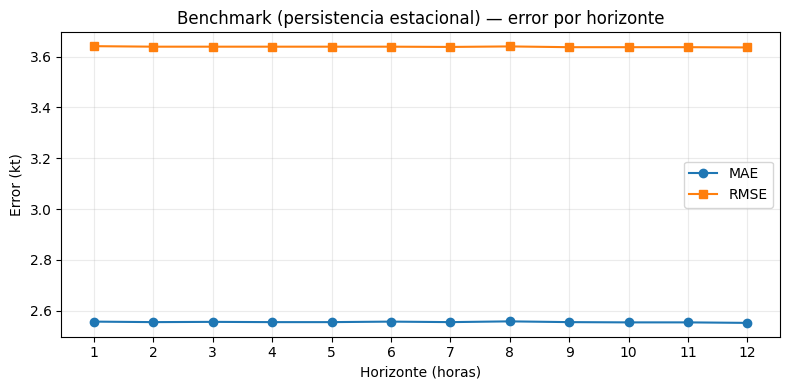

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(bench_h.index, bench_h["MAE"], marker="o", label="MAE")
ax.plot(bench_h.index, bench_h["RMSE"], marker="s", label="RMSE")
ax.set_title("Benchmark (persistencia estacional) — error por horizonte")
ax.set_xlabel("Horizonte (horas)")
ax.set_ylabel("Error (kt)")
ax.set_xticks(range(1, HORIZONTE + 1))
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()

### Desempeño del benchmark

La tabla y el gráfico anteriores muestran MAE, RMSE y R² del benchmark para cada horizonte de 1 a 12 horas. Observaciones:

- **Error casi constante con el horizonte.** Como la predicción siempre se construye con un dato de 24 h atrás, no importa cuán lejos esté el target dentro de las próximas 24 horas. El error se mantiene en el mismo orden. Este perfil plano será un contraste útil frente a modelos con memoria de corto plazo (SARIMA, redes neuronales), que tienden a degradarse a medida que se aleja el horizonte.
- **R² positivo pero bajo.** La estacionalidad diaria sola explica una fracción modesta de la varianza del viento, dejando margen amplio para que los modelos posteriores aporten información adicional vía lags cercanos y variables exógenas.

A partir de aquí, este será el desempeño mínimo que deben superar los modelos estocásticos y de redes neuronales para resultar útiles.

## Modelo estocástico

A partir de las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF) buscamos un modelo estocástico que ajuste bien la dinámica de `wind_avg`. El primer entregable ya mostró tres hechos relevantes para esta etapa:

- La prueba ADF sobre la serie original arrojó un estadístico de $-11.4$ y un $p$-valor de $7.6 \times 10^{-21}$, rechazando con holgura la hipótesis de raíz unitaria. **La serie es estacionaria**.
- El ACF mostró un pico claro en el lag 24 y el PACF resaltó los lags 1-2 y 20-24.
- El espectro de potencias estuvo dominado por la frecuencia de 1 ciclo/día, con un segundo pico (más débil) en 2 ciclos/día.

### ¿Por qué SARIMA y no AR, MA, ARMA o ARIMA?

La materia presenta la familia de modelos en escalera: AR, MA, ARMA (estacionarios), ARIMA (no estacionarios por tendencia, vía diferenciación regular) y SARIMA (cuando además hay estructura estacional). La elección entre ellos no es discrecional, se desprende de qué muestre la serie. Las reglas son:

| Modelo | ACF esperado | PACF esperado |
|---|---|---|
| AR($p$) | decae | corta en lag $p$ |
| MA($q$) | corta en lag $q$ | decae |
| ARMA($p,q$) | decae | decae |

- **AR puro queda descartado.** La PACF de `wind_avg` no corta limpio: tiene un primer cluster de 2 lags significativos (1-2) y otro cluster alrededor de los lags 20-24. Para que un AR(p) capture el pico de lag 24 con la PACF cortando ahí, haría falta $p = 24$ (24 coeficientes), violando el criterio de parsimonia.
- **MA puro queda descartado.** El ACF no corta en ningún lag corto: decae con oscilaciones (efecto día/noche en lag 12, pico positivo en lag 24). Un MA(q) requiere que la ACF se anule a partir de cierto $q$, condición que aquí no se cumple.
- **ARMA estacional-agnóstico queda descartado.** ARMA puede modelar un ACF/PACF que decaen, pero no incorpora la noción de **período**. El pico aislado en lag 24 de la ACF es estacional, no una correlación corta extendida, y un ARMA tendría que aproximarla con muchos coeficientes consecutivos. El espectro de potencias confirma que el ciclo diario es la fuente dominante de varianza, no ruido autocorrelacionado de corto alcance.
- **ARIMA queda descartado porque no hace falta diferenciación regular.** El ADF confirma estacionariedad, así que $d = 0$ y ARIMA(p,0,q) colapsa al ARMA ya descartado.
- **SARIMA es el ajuste natural.** Modela explícitamente la estacionalidad con un solo término $P$ o $Q$ aplicado al rezago $\mathbf{B}^{24}$:

$$\Theta_P(\mathbf{B}^{24})\,\Theta_p(\mathbf{B})\,(1-\mathbf{B}^{24})^{D}\,(1-\mathbf{B})^{d}\,x_t = \Phi_Q(\mathbf{B}^{24})\,\Phi_q(\mathbf{B})\,w_t$$

Así un único coeficiente estacional reemplaza decenas de coeficientes no estacionales. Tomamos $d = 0$ (ADF) y, en principio, $D = 0$ porque el ADF también pasa sobre la serie no diferenciada y el pico estacional ya está presente sin necesidad de remover una tendencia estacional. Si los residuos del modelo final muestran estructura sobreviviente cerca de múltiplos de 24, reconsideramos $D = 1$.

El modelo a explorar es entonces un **SARIMA(p,0,q)(P,0,Q,24)**, dejando para la búsqueda con AIC la elección concreta de $p, q, P, Q$. Toda la búsqueda y el diagnóstico se hacen sobre `serie_train` (el 80 % inicial ya definido arriba).

### Funciones de autocorrelación sobre el training

Repetimos el análisis del entregable 1 pero **solo sobre el subconjunto de training**, para evitar mirar el test al elegir los hiperparámetros. Esto es importante metodológicamente: cualquier inspección que hagamos para definir el modelo (orden, estacionalidad) debe basarse exclusivamente en datos vistos.

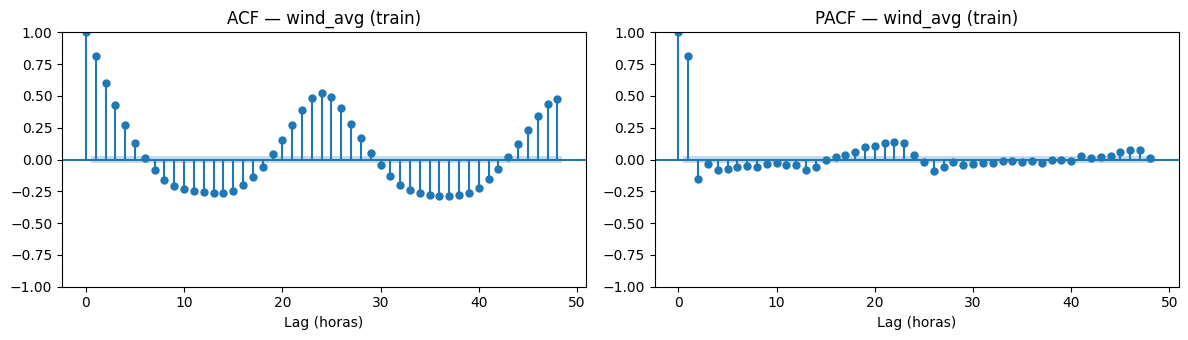

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(serie_train, lags=48, bartlett_confint=False, ax=axes[0])
axes[0].set_title("ACF — wind_avg (train)")
axes[0].set_xlabel("Lag (horas)")

plot_pacf(serie_train, lags=48, ax=axes[1])
axes[1].set_title("PACF — wind_avg (train)")
axes[1].set_xlabel("Lag (horas)")

plt.tight_layout()

El comportamiento sobre el training reproduce lo observado en el entregable 1: PACF significativa en lags 1-2 y entre 20-24, ACF con decaimiento lento y pico positivo en lag 24. Esto confirma la elección de SARIMA argumentada arriba y permite definir la grilla a explorar:

- $p \in \{0, 1, 2\}$ (PACF significativa hasta lag 2)
- $q \in \{0, 1\}$ (MA corto opcional)
- $P, Q \in \{0, 1\}$ (un solo término estacional alcanza para capturar el pico de lag 24)
- $d = D = 0$, $s = 24$, `trend = 'c'`

Son $3 \times 2 \times 2 \times 2 = 24$ combinaciones, en línea con el criterio de **parsimonia**.

### Selección del orden con el criterio de Akaike (AIC)

Iteramos sobre la grilla y, para cada combinación, ajustamos un SARIMA con `statsmodels.tsa.arima.model.ARIMA` y registramos el AIC. El AIC se define como

$$\mathrm{AIC} = -2 \log \mathcal{L} + 2 k$$

donde $\mathcal{L}$ es la verosimilitud del modelo y $k$ es el número de parámetros. Penaliza la cantidad de parámetros, por lo que minimizarlo selecciona el modelo más simple compatible con los datos (criterio de parsimonia). Envolvemos el ajuste en `try/except` para descartar combinaciones que no converjan.

In [6]:
from itertools import product
from tqdm import tqdm
from statsmodels.tsa.arima.model import ARIMA

ps, qs, Ps, Qs = [0, 1, 2], [0, 1], [0, 1], [0, 1]
S = 24

aic_final_df = pd.DataFrame({"p": [], "q": [], "P": [], "Q": [], "AIC": []})

for p, q, P, Q in tqdm(list(product(ps, qs, Ps, Qs))):
    try:
        model = ARIMA(
            serie_train,
            order=(p, 0, q),
            seasonal_order=(P, 0, Q, S),
            trend="c",
        )
    except:
        continue
    res = model.fit()
    aic_df = pd.DataFrame({"p": [p], "q": [q], "P": [P], "Q": [Q], "AIC": [res.aic]})
    aic_final_df = pd.concat([aic_final_df, aic_df])

aic_final_df.sort_values(by="AIC").reset_index(drop=True).head(10)

  0%|          | 0/24 [00:00<?, ?it/s]

  4%|▍         | 1/24 [00:00<00:11,  2.07it/s]

  8%|▊         | 2/24 [00:03<00:43,  1.98s/it]

 12%|█▎        | 3/24 [00:05<00:44,  2.10s/it]

 17%|█▋        | 4/24 [00:30<03:43, 11.17s/it]

...

 92%|█████████▏| 22/24 [03:01<00:17,  8.78s/it]

 96%|█████████▌| 23/24 [03:14<00:09,  9.87s/it]

100%|██████████| 24/24 [03:36<00:00, 13.49s/it]

100%|██████████| 24/24 [03:36<00:00,  9.01s/it]

,p,q,P,Q,AIC
0,2.0,1.0,1.0,1.0,20496.123448
1,1.0,1.0,1.0,1.0,20501.470215
2,2.0,0.0,1.0,1.0,20503.666777
3,1.0,0.0,1.0,1.0,20514.752748
4,2.0,1.0,1.0,0.0,21167.279026
5,2.0,1.0,0.0,1.0,21198.973119
6,2.0,0.0,1.0,0.0,21220.108075
7,1.0,1.0,1.0,0.0,21220.480090
8,1.0,0.0,1.0,0.0,21267.506863
9,2.0,0.0,0.0,1.0,21268.067111


La tabla anterior ordena las 24 combinaciones por AIC creciente. Tomamos como modelo ganador la primera fila (AIC mínimo).

### Ajuste del modelo ganador

Refitteamos el orden ganador —**SARIMA(2,0,1)(1,0,1,24)**— para inspeccionar los coeficientes con `summary()`: nos interesa ver si todos los términos son estadísticamente significativos (columna `P>|z|` cerca de cero) y si las raíces de los polinomios caen fuera del círculo unitario (condición de estacionariedad e invertibilidad).

In [7]:
best_order = aic_final_df.iloc[np.argmin(aic_final_df["AIC"]), :]
p_best, q_best = int(best_order["p"]), int(best_order["q"])
P_best, Q_best = int(best_order["P"]), int(best_order["Q"])

print(f"Mejor orden: SARIMA({p_best},0,{q_best})({P_best},0,{Q_best},{S})  "
      f"— AIC = {best_order['AIC']:.2f}")

modelo_best = ARIMA(
    serie_train,
    order=(p_best, 0, q_best),
    seasonal_order=(P_best, 0, Q_best, S),
    trend="c",
)
res_best = modelo_best.fit()
res_best.summary()

Mejor orden: SARIMA(2,0,1)(1,0,1,24)  — AIC = 20496.12


<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                     
========================================================================================
Dep. Variable:                         wind_avg   No. Observations:                 4916
Model:             ARIMA(2, 0, 1)x(1, 0, 1, 24)   Log Likelihood              -10241.062
Date:                          Wed, 27 May 2026   AIC                          20496.123
Time:                                  12:41:11   BIC                          20541.625
Sample:                              08-01-2025   HQIC                         20512.085
                                   - 02-21-2026                                         
Covariance Type:                            opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.2394      0.731      7.170      0.000       3.807       6.672
ar.L1          0.2532      0.145      1.745      0.081      -0.031       0.538
ar.L2          0.3016      0.107      2.809      0.005       0.091       0.512
ma.L1          0.5062      0.142      3.567      0.000       0.228       0.784
ar.S.L24       0.9964      0.001    912.401      0.000       0.994       0.999
ma.S.L24      -0.9544      0.005   -210.458      0.000      -0.963      -0.946
sigma2         3.7505      0.045     83.941      0.000       3.663       3.838
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):              7252.76
Prob(Q):                              0.78   Prob(JB):                         0.00
Heteroskedasticity (H):               0.93   Skew:                             1.29
Prob(H) (two-sided):                  0.16   Kurtosis:                         8.36
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Diagnóstico de residuos

Para confirmar que el orden elegido es adecuado revisamos los residuos: si el modelo captura toda la estructura, los residuos deben comportarse como un ruido blanco (independientes, idénticamente distribuidos, media cero). Usamos `plot_diagnostics()` de statsmodels, que agrupa:

1. **Residuos estandarizados en el tiempo:** no debería verse tendencia, heterocedasticidad ni outliers sistemáticos.
2. **Histograma + KDE comparados con $\mathcal{N}(0,1)$:** los residuos deberían ajustarse razonablemente a una normal.
3. **Q-Q plot:** los puntos deberían alinearse sobre la diagonal; desvíos en las colas indican distribuciones de cola pesada.
4. **Correlograma de los residuos:** todos los lags deberían quedar dentro de la banda de confianza, sin estructura sobreviviente.

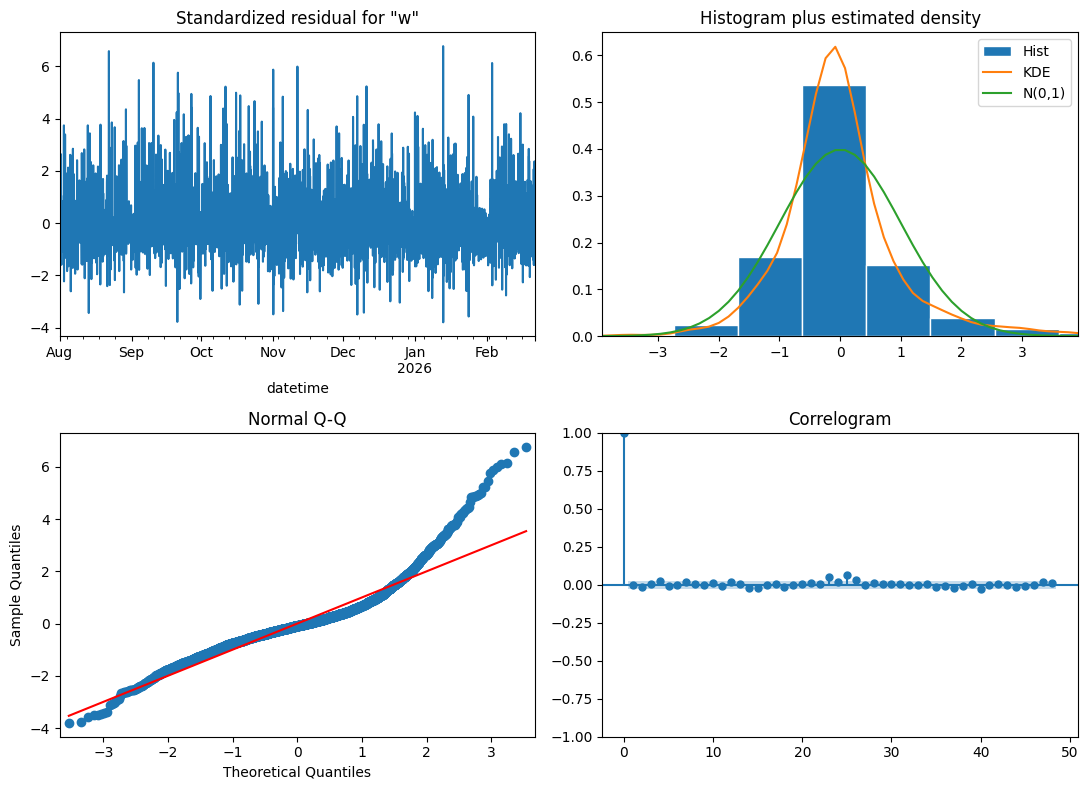

In [8]:
res_best.plot_diagnostics(figsize=(11, 8), lags=48)
plt.tight_layout()

**Interpretación del diagnóstico:**

- **Residuos estandarizados en el tiempo:** oscilan alrededor de 0 sin tendencia ni cambio sistemático de varianza. Se ven algunos picos aislados de magnitud 4-7 (outliers) repartidos a lo largo de toda la serie, sin formar clusters que sugieran heterocedasticidad fuerte.
- **Histograma + KDE vs $\mathcal{N}(0,1)$:** la forma de la distribución empírica (KDE en naranja) no coincide con la normal de referencia (verde): hay más masa concentrada cerca de 0 (pico más alto) y más masa en las colas (al menos en la derecha), con menos masa en la zona intermedia. Sin embargo, las dos cosas se compensan y la varianza total se mantiene cerca de 1, pero la forma no es gaussiana.
- **Q-Q plot:** los puntos se alinean con la diagonal en el centro y en la cola izquierda (de $-3$ a $-1$ la desviación es mínima). El problema está en la cola derecha: a partir de $+1.5$ los _Sample Quantiles_ se elevan muy por encima de la diagonal (llegan a 6-7 cuando los _Theoretical Quantiles_ correspondientes son solo 3). Esto indica asimetría positiva: el modelo predice bien los vientos bajos y normales pero subestima los picos altos de `wind_avg` (rachas, eventos térmicos intensos). Tiene sentido físico porque la distribución del viento es asimétrica (no puede ser muy negativa, pero puede subir mucho) y los residuos heredan esa asimetría.
- **Correlograma:** la gran mayoría de los lags del 1 al 48 caen dentro de la banda de confianza del 95%. Hay un par de lags (23 y 25) que asoman apenas por encima de la banda. Con 48 lags graficados es esperable por puro azar estadístico que algunos pocos caigan fuera del 95% aunque los residuos sean ruido blanco perfecto, así que estos excesos chicos justo en la zona estacional no justifican complicar el modelo. La lectura general es que el SARIMA absorbió la estructura temporal y la selección del orden $(p, q, P, Q)$ obtenida por AIC queda validada.

El modelo es válido para pronóstico puntual de `wind_avg`: la condición de ruido blanco (autocorrelación nula) se cumple, que es la hipótesis crítica del ajuste por máxima verosimilitud. La no-normalidad de los residuos (en el Q-Q plot) es esperable en series meteorológicas (eventos de viento extremos, rachas atípicas) y no invalida los coeficientes estimados; sin embargo, debe tenerse en cuenta al construir intervalos de confianza para las predicciones, ya que los basados en la hipótesis gaussiana van a subestimar la probabilidad de eventos extremos.

Con el modelo seleccionado y validado por residuos, queda definido el modelo estocástico de referencia. En la próxima sección lo evaluaremos sobre `serie_test` con un walk-forward idéntico al del benchmark y compararemos su desempeño contra la persistencia estacional.

#### Honestidad sobre el modelo elegido

Dos coeficientes del modelo ganador merecen una nota:

- **`ar.L1 = 0.2533` queda al borde de la significancia** (P>|z| = 0.081, no significativo al 5 %). El segundo orden por AIC, SARIMA(1,0,1)(1,0,1,24), está apenas 5 puntos por arriba (AIC 20501 vs 20496). El mínimo no es contundente; tomamos el ganador del criterio aplicado, pero la diferencia entre los dos primeros candidatos es chica.
- **`ar.S.L24 = 0.9964` está casi sobre la frontera de la raíz unitaria estacional.** Esto cuestiona el supuesto $D = 0$ usado en la grilla: un AR estacional ≈ 1 sugiere que diferenciar estacionalmente ($D = 1$) podría capturar el ciclo diario más directamente.

Para chequearlo ajustamos dos variantes con $D = 1$ sobre `serie_train`:

| Modelo | AIC | `ar.S.L24` | Ljung-Box (lag 48) |
|---|---|---|---|
| SARIMA(2,0,1)(1,0,1,24) — actual | 20496 | 0.9964 (p ≈ 0) | p = 0.018 |
| SARIMA(2,0,1)(1,1,1,24) | 20428 | 0.0222 (p = 0.091, no sig.) | p = 0.069 |
| SARIMA(2,0,1)(0,1,1,24) | 20429 | — | — |

Dos observaciones:

1. **El AR estacional y la diferenciación estacional son representaciones equivalentes del mismo fenómeno.** Bajo $D = 1$ el coeficiente `ar.S.L24` colapsa a $\approx 0$ y deja de ser significativo, y el modelo sin AR estacional, SARIMA(2,0,1)(0,1,1,24), alcanza prácticamente el mismo AIC. Tener `ar.S.L24` ≈ 1 (sin diferenciar) y diferenciar estacionalmente (sin AR estacional) son dos formas distintas de escribir el mismo proceso subyacente.
2. **Los lags 23 y 25 del correlograma de residuos no desaparecen con $D = 1$**; de hecho, su magnitud crece levemente. Esto confirma que esos picos son ruido aleatorio (al graficar 48 lags al 95 % es esperable que algunos asomen) y no señal estacional residual que el modelo esté dejando afuera.

**Decisión:** mantenemos SARIMA(2,0,1)(1,0,1,24) por consistencia con el espacio de búsqueda definido en la grilla ($d = D = 0$) y porque los dos caminos representan el mismo proceso. Declaramos como parte de la honestidad del ajuste los dos puntos delicados (`ar.L1` marginal y raíz unitaria estacional implícita) y dejamos para una eventual extensión la grilla con $D \in \{0, 1\}$.

## Evaluación del modelo estocástico

### Metodología (windowing)

Evaluamos SARIMA con la misma estrategia que usamos para el benchmark. Ajustamos el modelo una vez sobre `serie_train` y guardamos `serie_test` para reportar métricas. Como la consigna pide métricas según el horizonte (hasta h = 12), evaluamos predicciones de forma iterativa con un **walk-forward** sobre `serie_test`.

El procedimiento avanza origen por origen del test.

1. Para cada origen $t$ producimos un pronóstico a 12 h con `forecast(steps=12)` y registramos $\hat{y}_{t+1}, \dots, \hat{y}_{t+12}$.
2. Antes de avanzar al siguiente origen, incorporamos la observación recién pronosticada al estado del modelo con `append(refit=False)`, **sin re-estimar coeficientes**, igual que pasaría en operación. En vez de extender el modelo de una sola vez sobre todo el test, lo extendemos paso a paso para que cada predicción solo use información hasta el instante anterior.

Este patrón `forecast(...) → append(refit=False)` es el que recomienda la documentación de `statsmodels` para evaluación walk-forward eficiente.

**¿Por qué no re-fittear en cada origen?** Re-estimar parámetros en cada uno de los ~1200 orígenes implicaría ajustar SARIMA estacional ($s=24$) más de mil veces, con un costo computacional enorme para una mejora marginal. Lo habitual es entrenar al inicio y solo actualizar el estado dentro del test.

Calculamos MAE, RMSE y R² por horizonte con la misma función `metricas_por_horizonte` que usamos para el benchmark, así ambas tablas quedan directamente comparables.

In [9]:
res_walk = ARIMA(
    serie_train,
    order=(p_best, 0, q_best),
    seasonal_order=(P_best, 0, Q_best, S),
    trend="c",
).fit()

preds_sarima = {h: ([], []) for h in range(1, HORIZONTE + 1)}

for j in tqdm(range(n_origenes)):
    fc = res_walk.forecast(steps=HORIZONTE).to_numpy()
    for h in range(1, HORIZONTE + 1):
        target_idx = n_train + j + h - 1
        preds_sarima[h][0].append(serie.iloc[target_idx])
        preds_sarima[h][1].append(fc[h - 1])
    if j < n_origenes - 1:
        res_walk = res_walk.append(
            serie.iloc[n_train + j : n_train + j + 1], refit=False
        )

sarima_h = metricas_por_horizonte(preds_sarima)
sarima_h

  0%|          | 0/1218 [00:00<?, ?it/s]

  0%|          | 1/1218 [00:00<09:58,  2.03it/s]

  0%|          | 2/1218 [00:01<11:15,  1.80it/s]

  0%|          | 3/1218 [00:01<11:17,  1.79it/s]

  0%|          | 4/1218 [00:02<10:46,  1.88it/s]

...

100%|█████████▉| 1215/1218 [10:17<00:01,  1.75it/s]

100%|█████████▉| 1216/1218 [10:18<00:01,  1.76it/s]

100%|█████████▉| 1217/1218 [10:18<00:00,  1.77it/s]

100%|██████████| 1218/1218 [10:18<00:00,  1.97it/s]

,MAE,RMSE,R²
horizonte,,,
1,1.297,1.878,0.778
2,1.727,2.398,0.639
3,1.894,2.586,0.581
4,1.977,2.658,0.557
5,2.014,2.691,0.545
6,2.029,2.703,0.541
7,2.044,2.720,0.535
8,2.050,2.728,0.531
9,2.046,2.726,0.532


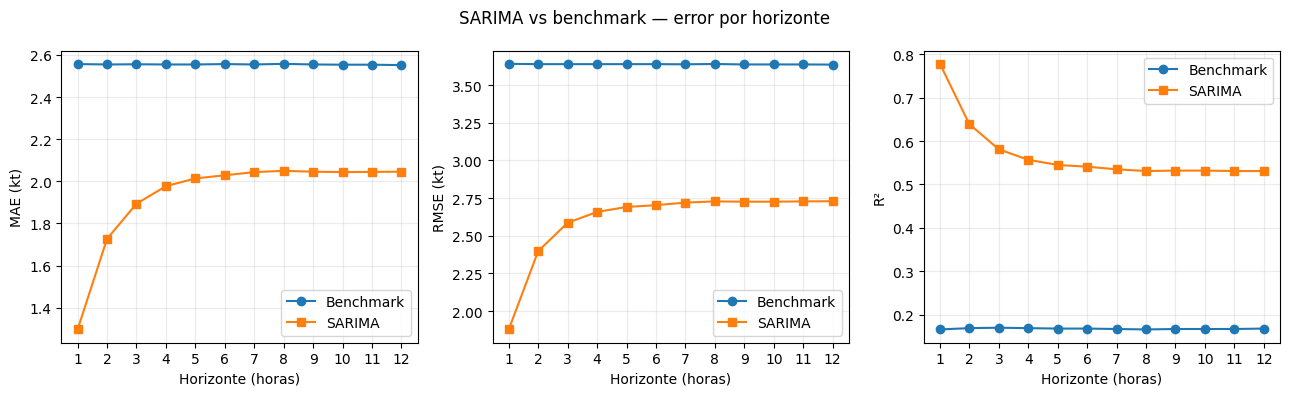

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col in zip(axes, ["MAE", "RMSE", "R²"]):
    ax.plot(bench_h.index, bench_h[col], marker="o", label="Benchmark")
    ax.plot(sarima_h.index, sarima_h[col], marker="s", label="SARIMA")
    ax.set_xlabel("Horizonte (horas)")
    ax.set_ylabel(col + (" (kt)" if col != "R²" else ""))
    ax.set_xticks(range(1, HORIZONTE + 1))
    ax.legend()
    ax.grid(alpha=0.25)

fig.suptitle("SARIMA vs benchmark — error por horizonte")
plt.tight_layout()

### Interpretación de los resultados

La tabla anterior y los gráficos comparan SARIMA contra el benchmark en MAE, RMSE y R² horizonte por horizonte. Lo más relevante.

- **SARIMA supera al benchmark en todos los horizontes.** Las curvas no se cruzan. Incluso en el horizonte más largo el RMSE de SARIMA queda por debajo del benchmark, y el R² del modelo estocástico es varias veces mayor que el de la persistencia estacional.
- **Degradación marcada en los primeros pasos y meseta a partir de h ≈ 6.** El RMSE crece rápido desde h = 1 y después se estanca. Esto se entiende mirando la estructura del modelo. El bloque AR(2)/MA(1) tiene raíces dentro del círculo unitario que decaen rápido (~5-6 pasos), mientras que el bloque estacional $(1,0,1,24)$, con `ar.S.L24` muy cercano a 1, se comporta como un patrón cíclico estable. A horizontes largos la predicción converge esencialmente a la media condicional más el ciclo diario, y de ahí no baja más.
- **La meseta queda por encima del benchmark.** A horizontes lejanos SARIMA y benchmark usan la misma información (el ciclo de 24 h), pero SARIMA trabaja con una estimación suavizada del ciclo, mientras que el benchmark copia un único dato ruidoso de ayer. Esa diferencia de varianza explica la brecha que queda entre las dos curvas.

Con esto queda evaluado el modelo estocástico. La línea de base sube bastante respecto al benchmark, así que cualquier red neuronal que entrenemos en la próxima sección va a tener que superar estas cifras para justificar su complejidad.

## Modelo de redes neuronales

Para el pronóstico de `wind_avg` a 12 h armamos modelos de redes neuronales (LSTM endógeno). A diferencia de SARIMA, una red neuronal no asume un proceso lineal y aprende una función cualquiera desde una ventana de pasos pasados hacia los 12 pasos futuros. Eso obliga a agregar dos pasos de preprocesamiento que no hacían falta en SARIMA.

- **Normalización** de la entrada, para que el optimizador trabaje en una escala controlada y los pesos no exploten en la primera época.
- **Ventaneo**, para transformar la serie temporal continua en pares $(X_i, y_i)$ que la red pueda consumir como muestras independientes.

Mantenemos `serie_train` y `serie_test` (con el split 80/20 ya definido) y conservamos el horizonte de 12 h y la frecuencia horaria. Para cubrir lo que pide la consigna probamos **tres configuraciones**, una red densa de referencia, una LSTM simple con dropout y una LSTM apilada con `return_sequences=True`.

### Normalización y ventaneo

**Normalización Z-score con estadísticos del train.** Restamos la media y dividimos por la desviación estándar calculadas **solo sobre `serie_train`**, y aplicamos esa misma transformación a `serie_test`. Así evitamos filtrar información del test al ajuste y dejamos la entrada centrada en 0 con varianza 1. Aprovechamos para castear a `float32`, el `dtype` por defecto de Keras.

**Ventaneo sequence-to-vector con salida multi-paso.** Recorremos la serie con paso 1 y, para cada origen $i$, formamos los pares siguientes.

- $X_i = (x_i, x_{i+1}, \dots, x_{i+W-1})$ — los $W$ valores pasados,
- $y_i = (x_{i+W}, x_{i+W+1}, \dots, x_{i+W+H-1})$ — los $H = 12$ valores futuros que queremos predecir.

Tomamos $W = 48$ para meter **dos ciclos diarios completos** en la ventana de entrada, cubriendo varios ciclos estacionales y dándole a la red información estructural suficiente. La salida tiene dimensión $H = 12$. Configuramos la última capa densa con 12 unidades para predecir los 12 horizontes **en un solo paso** (*direct multi-step*). Es más simple que un esquema recursivo y evita el error acumulado de realimentar predicciones, lo que además deja la comparación con SARIMA más prolija.

In [11]:
import keras

keras.utils.set_random_seed(99)
print(f"keras {keras.__version__} | backend: {keras.backend.backend()}")

keras 3.14.1 | backend: tensorflow


In [12]:
train_mean = float(serie_train.mean())
train_std = float(serie_train.std())
print(f"Media (train): {train_mean:.2f} kt")
print(f"Desv. estándar (train): {train_std:.2f} kt")

train_scaled = ((serie_train - train_mean) / train_std).to_numpy(dtype=np.float32)
test_scaled = ((serie_test - train_mean) / train_std).to_numpy(dtype=np.float32)

WINDOW_SIZE = 48


def ventanas_multistep(s, window, horizonte):
    X, y = [], []
    for i in range(len(s) - window - horizonte + 1):
        X.append(s[i : i + window])
        y.append(s[i + window : i + window + horizonte])
    return (
        np.array(X, dtype=np.float32)[..., np.newaxis],
        np.array(y, dtype=np.float32),
    )


X_train_nn, y_train_nn = ventanas_multistep(train_scaled, WINDOW_SIZE, HORIZONTE)
X_test_nn, y_test_nn = ventanas_multistep(test_scaled, WINDOW_SIZE, HORIZONTE)

print(f"Train: X {X_train_nn.shape}, y {y_train_nn.shape}")
print(f"Test:  X {X_test_nn.shape}, y {y_test_nn.shape}")

Media (train): 5.31 kt
Desv. estándar (train): 3.68 kt
Train: X (4857, 48, 1), y (4857, 12)
Test:  X (1170, 48, 1), y (1170, 12)


### Arquitecturas propuestas

Las tres configuraciones comparten el bloque de entrada (`Input((48, 1))`) y la cabeza de salida (`Dense(12, activation='linear')`), y se diferencian en lo que pasa en el medio.

- **Dense**: red de referencia. `Flatten` aplana la ventana de 48 pasos a un vector de 48 valores y un único `Dense(12)` aprende coeficientes lineales hacia cada horizonte. En el fondo es una regresión lineal múltiple sobre los lags, y sirve para medir cuánto aporta la estructura recurrente cuando la agreguemos.
- **LSTM**: una capa `LSTM(32)` recorre la ventana paso a paso y entrega el estado oculto final como vector de 32 features, seguida de `Dropout(0.2)` (durante el entrenamiento desactiva al azar el 20 % de las unidades para regularizar y evitar coadaptación) y el `Dense(12)` de salida.
- **LSTM-2capas**: apila dos LSTM. La primera usa `return_sequences=True` para entregar la secuencia completa de estados ocultos (no solo el último), así la segunda LSTM puede operar sobre esa secuencia. Cada LSTM va seguida de su `Dropout(0.2)`. Sirve para ver si más profundidad ayuda a capturar dinámica no lineal adicional.

El optimizador es Adam y la pérdida es MSE. Fijamos la semilla de Keras a 99 para que los pesos iniciales y el dropout sean reproducibles entre corridas.

In [13]:
def build_dense():
    m = keras.Sequential(
        [
            keras.layers.Input((WINDOW_SIZE, 1)),
            keras.layers.Flatten(),
            keras.layers.Dense(HORIZONTE, activation="linear"),
        ],
        name="Dense",
    )
    m.compile(loss="mse", metrics=["mae"], optimizer="adam")
    return m


def build_lstm():
    m = keras.Sequential(
        [
            keras.layers.Input((WINDOW_SIZE, 1)),
            keras.layers.LSTM(32),
            keras.layers.Dropout(0.2),
            keras.layers.Dense(HORIZONTE, activation="linear"),
        ],
        name="LSTM",
    )
    m.compile(loss="mse", metrics=["mae"], optimizer="adam")
    return m


def build_lstm_deep():
    m = keras.Sequential(
        [
            keras.layers.Input((WINDOW_SIZE, 1)),
            keras.layers.LSTM(32, return_sequences=True),
            keras.layers.Dropout(0.2),
            keras.layers.LSTM(32),
            keras.layers.Dropout(0.2),
            keras.layers.Dense(HORIZONTE, activation="linear"),
        ],
        name="LSTM-2capas",
    )
    m.compile(loss="mse", metrics=["mae"], optimizer="adam")
    return m


for build in [build_dense, build_lstm, build_lstm_deep]:
    m = build()
    print(f"\n{m.name}: {m.count_params()} parámetros")
    m.summary()


Dense — 588 parámetros


Model: "Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12)             │           588 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 588 (2.30 KB)

 Trainable params: 588 (2.30 KB)

...

Model: "LSTM-2capas"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 48, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,068 (51.05 KB)

 Trainable params: 13,068 (51.05 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento

Entrenamos cada modelo sobre `X_train_nn` con `validation_split=0.1` (último 10 % del train como validación, manteniendo el orden temporal) y un `EarlyStopping` con `patience=5` sobre la pérdida de validación que restaura los mejores pesos cuando se corta. Dejamos `epochs=50` como tope y la convergencia decide cuándo parar.

In [14]:
histories_nn = {}
modelos_nn = {}

for build in [build_dense, build_lstm, build_lstm_deep]:
    keras.utils.set_random_seed(99)
    m = build()
    es = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    )
    h = m.fit(
        X_train_nn,
        y_train_nn,
        epochs=50,
        validation_split=0.1,
        callbacks=[es],
        verbose=0,
    )
    histories_nn[m.name] = h.history
    modelos_nn[m.name] = m
    print(
        f"{m.name:12s} → epochs ajustados: {len(h.history['loss']):2d}  "
        f"| val_loss min: {min(h.history['val_loss']):.4f}"
    )

Dense        → epochs ajustados: 50  | val_loss min: 0.6763


LSTM         → epochs ajustados: 23  | val_loss min: 0.6351


LSTM-2capas  → epochs ajustados: 15  | val_loss min: 0.6451


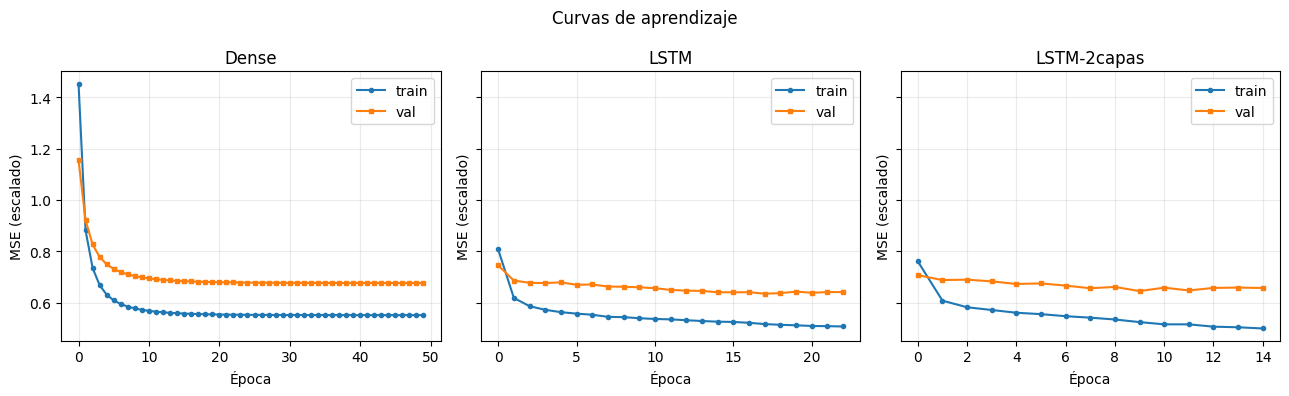

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, (nombre, hist) in zip(axes, histories_nn.items()):
    ax.plot(hist["loss"], label="train", marker="o", markersize=3)
    ax.plot(hist["val_loss"], label="val", marker="s", markersize=3)
    ax.set_title(nombre)
    ax.set_xlabel("Época")
    ax.set_ylabel("MSE (escalado)")
    ax.legend()
    ax.grid(alpha=0.25)

fig.suptitle("Curvas de aprendizaje")
plt.tight_layout()

### Resumen del ajuste

| Modelo | Parámetros | Épocas ajustadas | `val_loss` mínima |
|---|---|---|---|
| Dense | 588 | 50 (tope) | 0.676 |
| LSTM | 4 748 | 23 | 0.635 |
| LSTM-2capas | 13 068 | 15 | 0.645 |

Algunas lecturas de las curvas de aprendizaje.

- **Las dos LSTM dispararon EarlyStopping antes del tope** (23 y 15 épocas), señal de que la pérdida de validación dejó de mejorar y los pesos restaurados son los del mínimo histórico. La Dense llegó al tope de 50 épocas **sin** disparar `EarlyStopping`. Con esa cota su pérdida seguía bajando despacio, así que el 0.676 reportado es una cota superior y no necesariamente refleja el mínimo que alcanzaría con más épocas.
- **La LSTM simple obtiene la menor `val_loss`** (0.635 contra 0.645 de la apilada y 0.676 de la densa). La diferencia con la apilada (≈ 0.010) sale de **una sola semilla** (`seed = 99`) y puede estar dentro del ruido entre corridas. Una comparación más sólida exigiría promediar varias semillas y reportar media ± desvío, lo que no hicimos en esta entrega. Con esta única corrida lo que se puede afirmar es que **las dos LSTM quedan claramente por debajo de la Dense**, y entre LSTM y LSTM-2capas la diferencia no es concluyente.
- **Las curvas de train y validación divergen poco**, lo que indica que el dropout = 0.2 cumple su rol de regularización y no estamos sobreajustando de forma agresiva.

**Nota sobre el split de validación.** `validation_split=0.1` separa el último 10 % del array como validación **antes** del shuffle interno de `fit()`, así se preserva la separación temporal entre entrenamiento y validación. El shuffle se aplica solo al 90 % de entrenamiento, y es admisible porque, después del ventaneo, cada par $(X_i, y_i)$ se trata como una muestra independiente para el optimizador.

Las pérdidas están en la **escala normalizada** y promediadas sobre los 12 horizontes, así que no son directamente comparables con el RMSE en kt del benchmark o SARIMA. En la sección siguiente las redes pasan por el mismo walk-forward que aplicamos a SARIMA sobre `serie_test`, y eso nos permite reportar MAE, RMSE y R² por horizonte en escala kt.

## Evaluación de la red neuronal

### Modelo elegido y metodología

Del punto anterior elegimos la **LSTM simple**: obtuvo la menor `val_loss` (0.635 contra 0.645 de la apilada y 0.676 de la densa) y, frente a la LSTM de dos capas, alcanza ese desempeño con menos de la mitad de parámetros (4 748 vs 13 068). Por parsimonia nos quedamos con la más chica.

La evaluamos sobre `serie_test` con la **misma metodología que SARIMA**: un walk-forward que reporta MAE, RMSE y R² por horizonte (1 a 12 h) en kt, contrastado contra el **benchmark**, la línea de base que todo modelo debe superar. La comparación frente a SARIMA y la elección del modelo para una fase operativa quedan para el punto 8.

A diferencia de SARIMA, el formato es *direct multi-step*: una sola pasada de `predict()` sobre las ventanas de test (`X_test_nn`) devuelve los 12 horizontes a la vez. Cada fila $j$ de `X_test_nn` es un origen $t_j$ cuya predicción usa exclusivamente los 48 valores previos, así que metodológicamente equivale al loop `forecast → append(refit=False)` de SARIMA, sin recorrer orígenes a mano.

Dos detalles operativos:

- **Desnormalización antes de medir.** El modelo trabaja en escala $z$ (Z-score con `train_mean` y `train_std`), así que recuperamos kt con `y * train_std + train_mean` antes de calcular las métricas, dejando las tablas comparables con benchmark y SARIMA.
- **Offset respecto de SARIMA.** El ventaneo del test arranca en `serie_test.iloc[WINDOW_SIZE + h - 1]` y SARIMA en `serie_test.iloc[h - 1]`: la LSTM se evalúa sobre 1170 orígenes y SARIMA sobre 1218. La diferencia es chica y los promedios siguen siendo comparables, pero lo dejamos asentado.

In [16]:
modelo_lstm = modelos_nn["LSTM"]
y_test_kt = y_test_nn * train_std + train_mean
y_pred_kt = modelo_lstm.predict(X_test_nn, verbose=0) * train_std + train_mean

preds_lstm = {
    h: (y_test_kt[:, h - 1], y_pred_kt[:, h - 1])
    for h in range(1, HORIZONTE + 1)
}
lstm_h = metricas_por_horizonte(preds_lstm)
lstm_h

,MAE,RMSE,R²
horizonte,,,
1,1.558,2.147,0.710
2,1.889,2.589,0.580
3,2.028,2.759,0.524
4,2.100,2.841,0.494
5,2.141,2.882,0.479
6,2.171,2.907,0.470
7,2.185,2.911,0.468
8,2.192,2.901,0.472
9,2.199,2.907,0.470


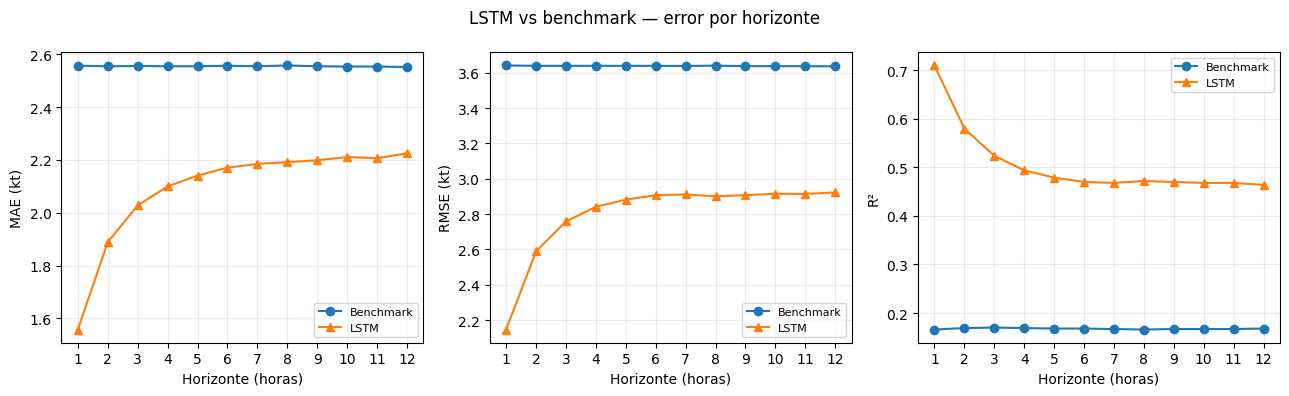

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col in zip(axes, ["MAE", "RMSE", "R²"]):
    ax.plot(bench_h.index, bench_h[col], marker="o", label="Benchmark")
    ax.plot(lstm_h.index, lstm_h[col], marker="^", label="LSTM")
    ax.set_xlabel("Horizonte (horas)")
    ax.set_ylabel(col + (" (kt)" if col != "R²" else ""))
    ax.set_xticks(range(1, HORIZONTE + 1))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

fig.suptitle("LSTM vs benchmark — error por horizonte")
plt.tight_layout()

### Interpretación de los resultados

La tabla y los gráficos comparan la LSTM contra el benchmark horizonte por horizonte.

- **La LSTM supera al benchmark en todos los horizontes.** En h = 1 el salto es grande: RMSE 2.15 kt contra 3.64 del benchmark y R² 0.71 contra 0.17. La red aprovecha la información de los lags cercanos de la ventana de 48 h, algo que la persistencia estacional (un único dato de 24 h atrás) no puede hacer.
- **Degradación marcada en los primeros pasos y meseta a partir de h ≈ 6.** El RMSE crece de 2.15 a ~2.9 kt entre h = 1 y h = 6 y después se estanca (el R² baja de 0.71 a ~0.47). Es el mismo perfil que SARIMA: la memoria de corto plazo aporta mucho en los primeros pasos y, a horizonte lejano, la predicción converge esencialmente al ciclo diario.
- **La meseta queda por debajo del benchmark.** Incluso en h = 12 la LSTM (RMSE 2.92 kt, R² 0.46) le gana a la persistencia estacional (RMSE 3.64, R² 0.17). A horizontes largos ambos se apoyan sobre todo en el ciclo de 24 h, pero la LSTM trabaja con una versión suavizada y no con un único dato ruidoso de ayer.

La LSTM elegida supera con claridad la línea de base. En el punto 8 la comparamos contra SARIMA y decidimos qué modelo llevaríamos a una fase operativa.

### ¿Los coeficientes son interpretables como importancia de atributos?

**No de forma directa.** Las tres redes entrenadas reúnen entre 588 (Dense) y 13 068 (LSTM-2capas) pesos, y la relación entre cada peso y "qué tan importante es un lag" no es la misma que en una regresión lineal.

- **Dense** es el único caso en el que los 588 pesos del único `Dense(48 → 12)` mapean *literalmente* {lag de entrada} × {horizonte de salida}, así que en principio se podrían leer como una matriz de coeficientes (es una regresión lineal múltiple). Pero incluso ahí la magnitud del peso no equivale a importancia. La entrada está normalizada (Z-score) y los 48 lags están **fuertemente correlacionados entre sí** (autocorrelación alta en lags 1-2 y 24), lo que reparte el "crédito" entre lags equivalentes y hace que los pesos individuales sean engañosos como ranking de importancia.
- **LSTM y LSTM-2capas** no admiten esa lectura. Los pesos de cada celda viven en matrices de forma $(d_\text{in} + d_h) \times 4 d_h$ que mezclan no linealmente input, estado oculto y los cuatro *gates* (input, forget, cell, output) a lo largo de los 48 pasos temporales. No hay correspondencia uno-a-uno entre un peso y un lag de entrada. La "importancia" de un lag depende de toda la trayectoria de estados ocultos, no de un coeficiente aislado.

**Alternativas estándar para asignar importancia a los lags** (las mencionamos pero no las implementamos porque la consigna no las pide).

- **Permutation importance por lag.** Después de entrenar, se permuta aleatoriamente cada lag del test (uno por vez) y se mide la caída en RMSE. Es agnóstica al modelo y se aplica igual a Dense, LSTM y LSTM-2capas.
- **Ablation por bloque temporal.** Anular bloques contiguos de lags (por ejemplo las últimas 6 horas, o las horas 18-24) y medir el impacto. Sirve para distinguir el aporte de corto plazo del estacional.
- **SHAP / Integrated Gradients.** Más caros computacionalmente, pero descomponen la predicción individual en aportes por lag.

Para un caso univariante como éste el espacio de "atributos" es simplemente {lag 1, …, lag 48}, así que **permutation importance** sería la opción más directa si quisiéramos responder cuantitativamente qué lags pesan más en cada modelo.

## Comparación de modelos y elección

Reunimos los cuatro modelos bajo la **misma metodología de evaluación** (walk-forward por horizonte sobre el 20 % final, métricas en kt) para una comparación justa:

- **Benchmark**: persistencia estacional (punto 3),
- **SARIMA**(2,0,1)(1,0,1,24) (punto 4),
- **LSTM** simple (punto 6),
- **LassoCV** del primer entregable.

### Re-evaluación del LassoCV bajo el mismo esquema

En el punto 5 dejamos pendiente comparar el LassoCV del entregable 1: allí se evaluó con validación cruzada sobre todo el dataset y sus cifras no eran comparables con el walk-forward de esta entrega. Acá saldamos esa deuda. Re-entrenamos el mismo pipeline (`StandardScaler → LassoCV` con `TimeSeriesSplit` para elegir $\alpha$) sobre el 80 % inicial y lo evaluamos sobre el 20 % final, horizonte por horizonte.

Tres aclaraciones:

- **Es el único modelo multivariante.** Usa 24 lags de `wind_avg` **más cinco exógenas** (`wind_max`, `temperature`, `rh`, `mslp`, `wind_direction`) y la hora codificada de forma cíclica, todas conocidas en el origen del pronóstico. Benchmark, SARIMA y LSTM son univariantes (solo `wind_avg`). La comparación responde entonces una pregunta concreta: **¿la información exógena justifica su costo frente a los modelos univariantes?**
- **Direct multi-step.** Igual que la LSTM, ajustamos un modelo por horizonte (`objetivo = wind_avg.shift(-h)`). Para no filtrar el test en el entrenamiento dejamos un `gap` de 12 h entre train y test.
- **Conteos de orígenes ligeramente distintos.** Como ya señalamos para la LSTM, el ventaneo hace que cada modelo se evalúe sobre una cantidad de orígenes algo diferente: benchmark y SARIMA sobre 1218, la LSTM sobre 1170 y el Lasso entre 1217 y 1228 según el horizonte. Los sub-períodos se solapan casi por completo, así que los promedios siguen siendo comparables, pero lo dejamos asentado por honestidad metodológica.

In [18]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LassoCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

N_LAGS = 24
EXOG = ["wind_max", "temperature", "rh", "mslp", "wind_direction"]


class LagFeatures(TransformerMixin, BaseEstimator):
    def __init__(self, lags=1):
        self.lags = lags

    def fit(self, X, y=None):
        self.X_mean = X.mean()
        return self

    def transform(self, X):
        out = pd.DataFrame(index=X.index)
        for col in X.columns:
            for lag in range(1, self.lags + 1):
                out[f"{col}_Lag_{lag}"] = X[col].shift(lag, fill_value=self.X_mean[col])
        return out


def crear_features(objetivo, exog, h):
    X = pd.concat([exog, LagFeatures(lags=N_LAGS).fit_transform(objetivo.to_frame())], axis=1)
    X["hora_sin"] = np.sin(2 * np.pi * X.index.hour / 24)
    X["hora_cos"] = np.cos(2 * np.pi * X.index.hour / 24)
    y = objetivo.shift(-h).rename("objetivo")
    return pd.concat([X, y], axis=1).dropna()


lasso_cv = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("modelo", LassoCV(cv=TimeSeriesSplit(n_splits=3), max_iter=20000,
                           n_jobs=-1, alphas=np.logspace(-4, 1, 100))),
    ]
)

df_ml = df.ffill().bfill()
split_ts = serie.index[n_train]
gap = pd.Timedelta(hours=HORIZONTE)

preds_lasso = {}
for h in range(1, HORIZONTE + 1):
    datos = crear_features(df_ml["wind_avg"], df_ml[EXOG], h)
    train = datos[datos.index < split_ts - gap]
    test = datos[datos.index >= split_ts]
    lasso_cv.fit(train.drop(columns="objetivo"), train["objetivo"])
    preds_lasso[h] = (test["objetivo"].to_numpy(),
                      lasso_cv.predict(test.drop(columns="objetivo")))

lasso_h = metricas_por_horizonte(preds_lasso)
lasso_h

,MAE,RMSE,R²
horizonte,,,
1,1.436,2.026,0.742
2,1.933,2.594,0.577
3,2.119,2.788,0.511
4,2.194,2.868,0.482
5,2.205,2.880,0.478
6,2.207,2.880,0.478
7,2.214,2.876,0.479
8,2.206,2.865,0.483
9,2.191,2.847,0.490


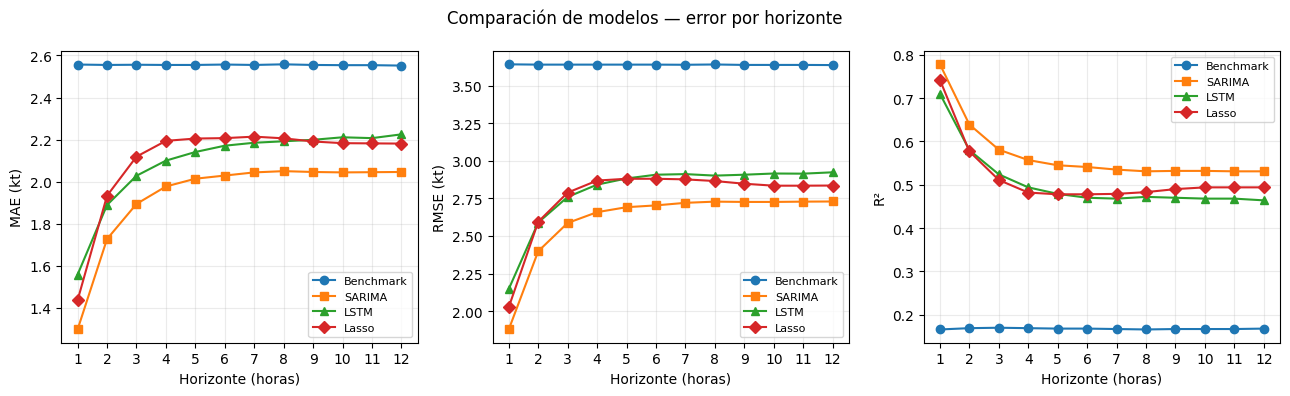

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

curvas = [
    ("Benchmark", bench_h, "o"),
    ("SARIMA", sarima_h, "s"),
    ("LSTM", lstm_h, "^"),
    ("Lasso", lasso_h, "D"),
]

for ax, col in zip(axes, ["MAE", "RMSE", "R²"]):
    for nombre, tabla, marker in curvas:
        ax.plot(tabla.index, tabla[col], marker=marker, label=nombre)
    ax.set_xlabel("Horizonte (horas)")
    ax.set_ylabel(col + (" (kt)" if col != "R²" else ""))
    ax.set_xticks(range(1, HORIZONTE + 1))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

fig.suptitle("Comparación de modelos — error por horizonte")
plt.tight_layout()

In [20]:
tablas = {"Benchmark": bench_h, "SARIMA": sarima_h, "LSTM": lstm_h, "Lasso": lasso_h}
resumen = pd.DataFrame({nombre: t.mean() for nombre, t in tablas.items()}).T.round(3)
resumen["Mejora % RMSE"] = ((1 - resumen["RMSE"] / resumen.loc["Benchmark", "RMSE"]) * 100).round(1)
resumen.sort_values("RMSE")

,MAE,RMSE,R²,Mejora % RMSE
SARIMA,1.934,2.606,0.569,28.4
Lasso,2.104,2.761,0.517,24.1
LSTM,2.092,2.800,0.506,23.0
Benchmark,2.555,3.638,0.168,0.0


### Interpretación y elección del modelo

El gráfico y la tabla resumen (medias sobre los 12 horizontes) ordenan a los cuatro modelos. Lecturas principales:

- **Los tres modelos superan al benchmark en todos los horizontes.** La persistencia estacional (RMSE ≈ 3.64 kt, R² ≈ 0.17, plana) queda muy por debajo: cualquiera de los modelos reduce el RMSE promedio entre 23 % y 28 %.
- **SARIMA es el mejor en todo el rango.** Tiene el menor RMSE y el mayor R² en cada horizonte (RMSE promedio 2.61 kt, R² 0.57). Su ventaja es máxima en el corto plazo (en h = 1 alcanza R² 0.78 contra 0.74 del Lasso y 0.71 de la LSTM) y se mantiene arriba hasta h = 12.
- **El Lasso y la LSTM quedan prácticamente empatados, y los dos por debajo de SARIMA.** El Lasso es algo mejor en RMSE (2.76 contra 2.80 kt) y R², pero la LSTM lo iguala en MAE (2.09 contra 2.10) e incluso le gana en los horizontes h2–h4 (las curvas se cruzan). Lo importante es que **ninguno supera a SARIMA**: pese a ser el único con información **exógena** (`wind_max`, temperatura, humedad, presión, dirección), el Lasso no consigue bajar su RMSE promedio (2.76 kt) por debajo del de SARIMA (2.61). Es el hallazgo central: **las cinco exógenas y los 24 lags no aportan lo suficiente como para superar a un SARIMA univariante bien especificado**, ni siquiera para despegarse de la LSTM, también univariante. La estructura autorregresiva y estacional de `wind_avg` ya contiene casi toda la señal predecible a esta resolución.
- **A horizontes largos los tres modelos convergen** (~2.7–2.9 kt de RMSE en h = 12): cuando el corto plazo deja de informar, todos se apoyan en el ciclo diario y las diferencias se achican.

**¿Qué modelo elegiríamos para una fase operativa? SARIMA.** Las razones:

1. **Mejor desempeño en todos los horizontes**, con la mayor ventaja justo donde más se usa un pronóstico de viento: las próximas horas.
2. **Robustez operativa.** Es univariante: solo necesita el histórico de `wind_avg`. No depende de cinco sensores exógenos que pueden fallar o llegar tarde y, de hecho, el único modelo que sí los usa (Lasso) no logra sacarles ventaja, así que esa dependencia extra no se justifica.
3. **Parsimonia e interpretabilidad.** Pocos parámetros, ajuste rápido (re-fitteable de forma periódica en operación) e intervalos de predicción nativos. Con la salvedad del punto 4: los residuos no son gaussianos, así que esos intervalos subestiman los eventos de viento extremo.
4. **La LSTM, la más compleja** (entrenamiento, sensibilidad a la semilla, menor interpretabilidad), no compensa: empata al Lasso y queda por debajo de SARIMA.

En síntesis, para esta serie y este horizonte el modelo estocástico ofrece la mejor relación desempeño/simplicidad/robustez.

## ¿Cómo se podría continuar el trabajo?

SARIMA quedó como modelo elegido, pero el análisis dejó varias puertas abiertas. Las continuaciones más prometedoras:

- **SARIMAX.** Incorporar las cinco exógenas *dentro* del SARIMA ganador, no como modelo aparte. Cerraría formalmente la pregunta central del trabajo —¿las exógenas aportan?— probándolas en el mejor modelo y no solo en el Lasso y la LSTM.
- **Modelos de volatilidad (GARCH) sobre los residuos.** El Q-Q plot mostró colas pesadas y asimetría positiva. Modelar la varianza condicional de los residuos daría intervalos de predicción honestos para los eventos de viento extremo, que hoy los intervalos gaussianos subestiman.
- **Codificar `wind_direction` como seno/coseno.** Quedó pendiente explícito: la dirección es circular (0° = 360°) y el Z-score rompe esa continuidad. La codificación trigonométrica la respeta y es un cambio de bajo costo.
- **Re-fitteo periódico del SARIMA en operación.** Hoy entrenamos una vez y solo actualizamos el estado. En producción la serie deriva (estaciones, cambios de instrumental), así que conviene definir cada cuánto re-estimar los coeficientes y medir el costo/beneficio frente a solo actualizar el estado.
- **Exógenas futuras (pronóstico meteorológico).** Las exógenas *pasadas* no ayudaron. Usar el *pronóstico* de temperatura, presión y humedad (no su histórico) como entrada es información distinta y podría sí aportar, sobre todo a horizontes largos donde el ciclo diario domina.